In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

BASE_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = BASE_DIR / "data"
REPORTS_DIR = BASE_DIR / "reports"
REPORTS_DIR.mkdir(exist_ok=True)

bonds = pd.read_csv(DATA_DIR / "bond_portfolio_data.csv")

total_mv = bonds["MarketValue_INR"].sum()

portfolio_duration = (
    bonds["ModifiedDuration"] * bonds["PortfolioWeight"]
).sum()

portfolio_convexity = (
    bonds["Convexity"] * bonds["PortfolioWeight"]
).sum()

print(f"Total Portfolio Value: ₹{total_mv:,.2f}")
print(f"Portfolio Duration: {portfolio_duration:.2f}")
print(f"Portfolio Convexity: {portfolio_convexity:.2f}")

Total Portfolio Value: ₹32,059,345.97
Portfolio Duration: 4.20
Portfolio Convexity: 44.06


In [2]:
shock_bps = [-200, -100, -50, -25, 25, 50, 100, 200]

stress_results = []

for bps in shock_bps:
    dy = bps / 10000

    duration_effect = -portfolio_duration * dy * total_mv
    convexity_effect = 0.5 * portfolio_convexity * (dy ** 2) * total_mv
    total_pnl = duration_effect + convexity_effect
    pnl_pct = total_pnl / total_mv

    stress_results.append({
        "Shock_bps": bps,
        "Duration_Effect_INR": duration_effect,
        "Convexity_Effect_INR": convexity_effect,
        "Total_PnL_INR": total_pnl,
        "PnL_Percentage": pnl_pct
    })

stress_df = pd.DataFrame(stress_results)

display(stress_df)

,Shock_bps,Duration_Effect_INR,Convexity_Effect_INR,Total_PnL_INR,PnL_Percentage
0,-200,2.694992e+06,282515.801827,2.977508e+06,0.092875
1,-100,1.347496e+06,70628.950457,1.418125e+06,0.044234
2,-50,6.737481e+05,17657.237614,6.914054e+05,0.021566
3,-25,3.368741e+05,4414.309404,3.412884e+05,0.010646
4,25,-3.368741e+05,4414.309404,-3.324597e+05,-0.010370
5,50,-6.737481e+05,17657.237614,-6.560909e+05,-0.020465
6,100,-1.347496e+06,70628.950457,-1.276867e+06,-0.039828
7,200,-2.694992e+06,282515.801827,-2.412477e+06,-0.075250


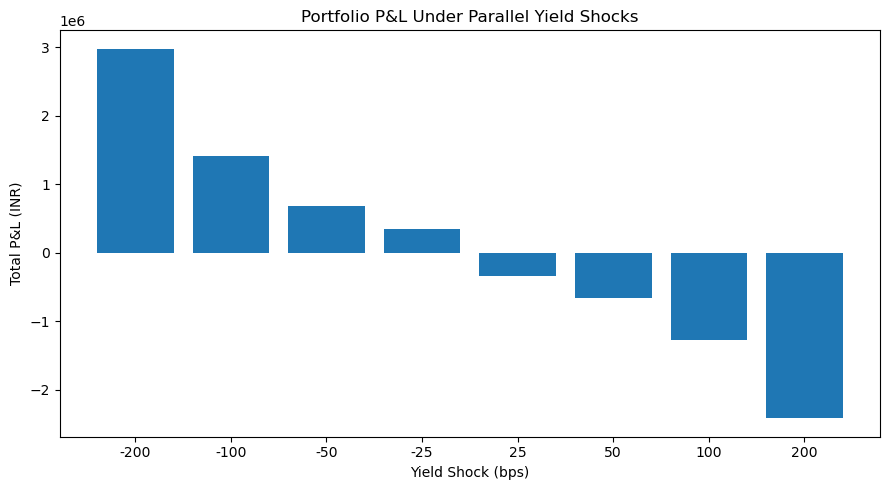

In [3]:
plt.figure(figsize=(9, 5))

plt.bar(
    stress_df["Shock_bps"].astype(str),
    stress_df["Total_PnL_INR"]
)

plt.title("Portfolio P&L Under Parallel Yield Shocks")
plt.xlabel("Yield Shock (bps)")
plt.ylabel("Total P&L (INR)")
plt.tight_layout()
plt.show()

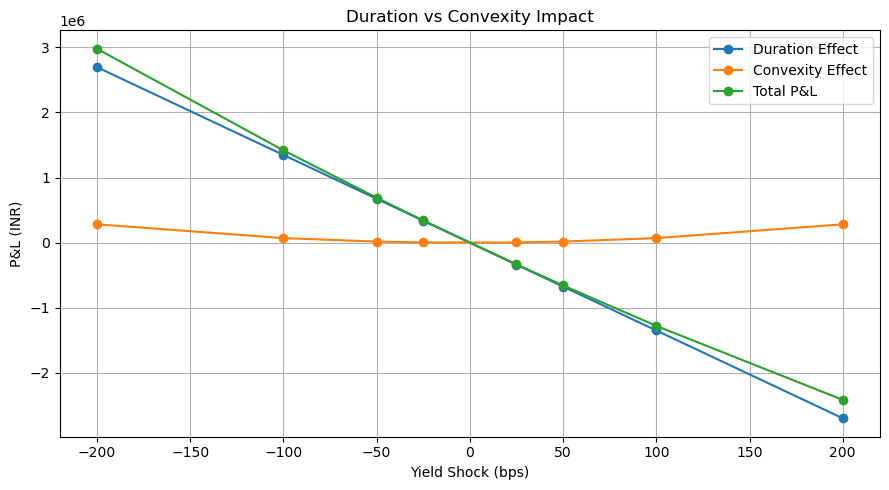

In [4]:
plt.figure(figsize=(9, 5))

plt.plot(
    stress_df["Shock_bps"],
    stress_df["Duration_Effect_INR"],
    marker="o",
    label="Duration Effect"
)

plt.plot(
    stress_df["Shock_bps"],
    stress_df["Convexity_Effect_INR"],
    marker="o",
    label="Convexity Effect"
)

plt.plot(
    stress_df["Shock_bps"],
    stress_df["Total_PnL_INR"],
    marker="o",
    label="Total P&L"
)

plt.title("Duration vs Convexity Impact")
plt.xlabel("Yield Shock (bps)")
plt.ylabel("P&L (INR)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [5]:
stress_summary = pd.DataFrame({
    "Metric": [
        "Worst Scenario",
        "Worst P&L",
        "Best Scenario",
        "Best P&L",
        "Portfolio Value",
        "Portfolio Duration",
        "Portfolio Convexity"
    ],
    "Value": [
        f"{stress_df.loc[stress_df['Total_PnL_INR'].idxmin(), 'Shock_bps']} bps",
        f"₹{stress_df['Total_PnL_INR'].min():,.2f}",
        f"{stress_df.loc[stress_df['Total_PnL_INR'].idxmax(), 'Shock_bps']} bps",
        f"₹{stress_df['Total_PnL_INR'].max():,.2f}",
        f"₹{total_mv:,.2f}",
        f"{portfolio_duration:.2f}",
        f"{portfolio_convexity:.2f}"
    ]
})

display(stress_summary)

,Metric,Value
0,Worst Scenario,200 bps
1,Worst P&L,"₹-2,412,476.67"
2,Best Scenario,-200 bps
3,Best P&L,"₹2,977,508.27"
4,Portfolio Value,"₹32,059,345.97"
5,Portfolio Duration,4.20
6,Portfolio Convexity,44.06


In [6]:
stress_df.to_csv(REPORTS_DIR / "stress_testing_day5.csv", index=False)
stress_summary.to_csv(REPORTS_DIR / "stress_testing_summary_day5.csv", index=False)

print("Day 5 stress testing results saved successfully.")

Day 5 stress testing results saved successfully.
